<a href="https://colab.research.google.com/github/AkhileshSR/AkhileshSR/blob/main/feb_2026_3_langgraph_crash_course_part_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangGraph Crash Course - Part 3: Tool Use & The ReAcT Pattern 🛠️

In Parts 1 & 2, our Agent could "Think". Now, we give it "Hands".

We will cover:
1.  **Tool Binding:** Teaching the LLM which tools it has.
2.  **The ReAcT Loop:** Implementing the cycle of **Reason** -> **Act** -> **Observe**.
3.  **Prebuilt ToolNode:** Using LangGraph's optimized node for running tools.

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_community langgraph tavily-python

In [ ]:
import os
import getpass

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key: ")

if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API Key: ")

Enter your OpenAI API Key: ··········
Enter your Tavily API Key: ··········


## 1. Defining Tools
Tools are just Python functions. We will create a simple Calculator and a Web Search tool.

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool

# 1. Custom Calculator Tool
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two integers together."""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Adds two integers together."""
    return a + b

# 2. Search Tool
web_search = TavilySearchResults(max_results=2)

tools = [multiply, add, web_search]

/tmp/ipython-input-705006397.py:11: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search = TavilySearchResults(max_results=2)


## 2. The Brain: Connecting Tools to LLM
We use `.bind_tools()` to tell the LLM: "Here are the functions you can call if you need to."

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

## 3. Building the ReAcT Graph
The ReAcT pattern (Reason + Act) is a loop:
1.  **Reason Node:** LLM looks at the input and decides: "Do I need a tool?" or "Do I have the answer?"
2.  **Conditional Edge:** If Tool needed -> Go to Tools. If Answer ready -> END.
3.  **Tool Node:** Executes the tool and returning the result.
4.  **Loop Back:** The tool result goes BACK to the Reason Node.

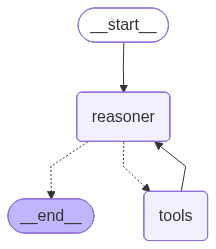

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# 1. State: We just need a list of messages
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 2. Nodes
def reasoner(state: State):
    # return the LLM's decision (Text or Tool Call)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# 3. Build Graph
builder = StateGraph(State)

builder.add_node("reasoner", reasoner)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "reasoner")

# 4. Conditional Edge
# tools_condition is a prebuilt function that checks message.tool_calls
builder.add_conditional_edges(
    "reasoner",
    tools_condition,
)

# 5. Loop Back
builder.add_edge("tools", "reasoner")

react_graph = builder.compile()

from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

## 4. Running the Agent
Let's test if it uses the tools correctly.

In [ ]:
# Test 1: Math (Should use multiply tool)
print("--- Test 1: Multipy ---")
res = react_graph.invoke({"messages": [("user", "What is 500 * 25?")]})
print(res["messages"][-1].content)

--- Test 1: Math ---
The result of 500 * 25 is 12,500.


In [ ]:
# Test 2: Search (Should use Tavily)
print("\n--- Test 2: Search ---")
res = react_graph.invoke({"messages": [("user", "Who is current CEO of OpenAI?")]})
print(res["messages"][-1].content)


--- Test 2: Search ---
The current CEO of OpenAI is Sam Altman. He has served in this role since 2019 and was briefly removed by the board on November 17, 2023, but was reinstated just five days later. You can read more about him [here](https://en.wikipedia.org/wiki/Sam_Altman).


In [ ]:
# Test 3: Chat (Should NOT use tools)
print("\n--- Test 3: Chat ---")
res = react_graph.invoke({"messages": [("user", "Hi there!")]})
print(res["messages"][-1].content)


--- Test 3: Chat ---
Hello! How can I assist you today?


In [ ]:
# Test 4: Math (Should use add tool)
print("--- Test 4: Add ---")
res = react_graph.invoke({"messages": [("user", "What is 500 + 25?")]})
print(res["messages"][-1].content)

In [ ]:
# --- Prebuilt ReAct agent ---
from langchain.agents import create_agent
from langchain_core.messages import SystemMessage, HumanMessage

agent = create_agent(
    model=llm,
    tools=tools,
)

# --------------------------
# Better example: "micro-business pricing helper"
# The agent should:
# 1) search a live fact (a current rate/number)
# 2) do a quick multiplication for a rough estimate
# --------------------------
messages = [
    SystemMessage(content=
        "You are a practical assistant. Use tools only when needed. "
        "When you use web search, cite what you found in plain words (no links). "
        "Keep answers short and actionable."
    ),
    HumanMessage(content=
        "I want a rough estimate: If a cloud GPU costs around the current on-demand hourly price "
        "for an NVIDIA T4 on any major provider, what would 120 hours cost? "
        "First, quickly look up a current hourly price estimate, then multiply by 120."
    )
]

result = agent.invoke({"messages": messages})

print(result["messages"][-1].content)

The current hourly price for an NVIDIA T4 GPU is approximately $0.35. For 120 hours, the total cost would be roughly $4200.


## Conclusion
You have built a **ReAcT Agent**!
It autonomously decided when to use tools and when to just talk.

**Next Up (Part 4):** We will add **Human-in-the-Loop** (Approval) and **Time Travel**.